# Machine Learning Fundamentals

## Types of Machine Learning Algorithms
Machine learning can be broadly categorized into three main types:

### 1. Supervised Learning
- The algorithm learns from labeled training data

- Goal: Predict the correct label for new, unseen data

- Examples:

    - Classification (spam detection, image recognition)

    - Regression (house price prediction, stock forecasting)

### 2. Unsupervised Learning
- The algorithm learns patterns from unlabeled data

- Goal: Discover hidden patterns or groupings in data

- Examples:

    - Clustering (customer segmentation, anomaly detection)

    - Dimensionality reduction (PCA)

```python
# Example of supervised vs unsupervised learning
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# Supervised
X, y = load_iris(return_X_y=True)  # X: features, y: labels
model.fit(X, y)

# Unsupervised
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)  # No y provided

## Regression vs Classification
### Regression
- Predicts continuous numerical values

- Examples: House prices, temperature, stock prices

- Algorithms:

    - Linear Regression

    - Polynomial Regression

    - Decision Tree Regression (Ensemble method)

    - Random Forest Regression (Ensemble method)

    - K-Nearest Neighbor(KNN) Regressor

### Classification
- Predicts discrete class labels

- Examples: Spam/not spam, disease diagnosis, image categories

- Algorithms:

    - Logistic Regression

    - Decision Trees

    - Random Forest

    - k-Nearest Neighbors (k-NN)

    - Gradient Boosting

    - XGBoost (Extreme Gradient Boosting)

Key Differences:

| Characteristic  | Regression | Classification |
|:--------:|:--------:|:--------:|
|  Output type   |  Continuous   |  Discrete   |
|  Evaluation   |  MSE, RMSE, R²   |  Accuracy, Precision, Recall, F1   |
|  Algorithms   |  Predicts continuous values   |  Predicts categories   |

```python
# Regression example
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)  # y_train is continuous

# Classification example
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)  # y_train is categorical

## Data Preprocessing
Proper data preprocessing is crucial for model performance:

### 1. Handling Missing Data
Options: Imputation `(mean/median/mode)`, deletion
```python
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

### 2. Feature Scaling
Feature scaling is crucial when features have different scales, as most machine learning algorithms perform better when features are on a similar scale.

Why Scale Features?
- Distance-based algorithms (k-NN, SVM, K-means) are sensitive to feature scales

- Gradient descent converges faster with scaled features

- Regularization penalties affect features equally only when scaled

Common Scaling Methods:
#### 2.1. Standardization (Z-score Normalization)
- Transforms features to have `μ=0 and σ=1`

- Formula: `x' = (x - μ) / σ`

- Best for: Normally distributed data (but works well in most cases)
```python
from sklearn.preprocessing import StandardScaler
X_train, X_test
scaler = StandardScaler()
X_scaled = scaler.fit(X)
X_scaled = scaler.transform(X_scaled)
X_scaled = scaler.fit_transform(X)

# For new data:
X_test_scaled = scaler.transform(X_test)  # Use same scaler!

#### 2. Min-Max Scaling (Normalization)
- Scales features to a fixed range `(usually [0, 1])`

- Formula: `x' = (x - min) / (max - min)`

- Best for: Bounded data, neural networks (where inputs need to be 0-1)
```python
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Feature Encoding
#### 3.1. Ordinal Encoding
- For categorical variables with inherent order

- Example: ["low", "medium", "high"] → [0, 1, 2]
```python
encoder = OrdinalEncoder(categories=[["low", "medium", "high"]])
X_encoded = encoder.fit_transform(X)

#### 3.2. One-Hot Encoding
- For nominal categories without inherent order

- Creates binary columns for each category

- Similar to Label Encoding, with the difference being that Label Encoding does not create additional columns
```python
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)

# With pandas:
pd.get_dummies(df, columns=["color"])

Encoding Best Practices:
- One-hot for few categories (<10)

- Ordinal when clear order exists

### 4. Logarithmic Transformations
Used to handle skewed data and make it more normally distributed

When to Transform:
- Right-skewed data (long tail to the right)

- For models that assume normality (linear regression)

Common Transformations:
#### 4.1. Logarithmic Transformation
- x' = log(x + ε) where ε is small constant for zeros

- Best for: Multiplicative relationships, exponential trends

```python
import numpy as np
X_log = np.log1p(X)  # log(x+1)

# before transformation
[1, 10, 100, 1000, 10000]

# after transformation
[0.0, 2.30, 4.60, 6.91, 9.21]

### 5. Handling Imbalanced Data
- Oversampling minority class (SMOTE)

- Undersampling majority class
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

# setting class weight to balanced
model=LogisticRegression(class_weight='balanced')
```

models with class_weight=balanced:
- LogisticRegression()
- DecisionTree()
- RandomForest()
- XGBoost()
- KNN()**

## Regularization Techniques
- Regularization prevents overfitting by adding penalty terms:

### 1. L1 Regularization (Lasso Regression)
- Adds absolute value of coefficients to loss function

- Performs feature selection (can shrink coefficients to zero)

- Formula: Loss + λΣ|wᵢ|

### 2. L2 Regularization (Ridge Regression)
- Adds squared value of coefficients to loss function

- Shrinks coefficients but doesn't eliminate them

- Formula: Loss + λΣwᵢ²
```python
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)  # alpha is λ
lasso = Lasso(alpha=0.1)

ridge.fit(X_train, y_train)

# Higher alpha means more regularization

## Hyperparameter Tuning
### Grid Search
Exhaustive search over specified parameter values

Evaluates all possible combinations

Uses cross-validation to find best parameters

```python
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10, 20, 30]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

## Summary
1. ML Types: Supervised (labeled data), Unsupervised (unlabeled patterns)

2. Tasks: Regression (continuous outputs) vs Classification (discrete categories)

3. Preprocessing: Cleaning, scaling, encoding, balancing data

4. Regularization: Lasso (L1), Ridge (L2) prevent overfitting

5. Tuning: Grid Search systematically finds optimal hyperparameters

In [1]:
# import the required libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# load the iris dataset
iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# check the info
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
# check the summary statistics
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# check for missing values and duplicates
print("Missing values:\n", df_iris.isnull().sum())
print("Duplicates:", df_iris.duplicated().sum())

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64
Duplicates: 1


In [6]:
# drop the duplicate row
df_iris.drop_duplicates()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
# split the dataset into features and target variable
X = df_iris.drop('target', axis=1)
y = df_iris['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# create a pipeline for preprocessing and model training
# define the numeric features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# create a preprocessor for numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

# create a logistic regression model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=200, random_state=42))
])

In [9]:
# fit the model to the training data
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# evaluate on the test set
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [12]:
# implement a Random Forest Classifier
pipeline.set_params(classifier=RandomForestClassifier(n_estimators=100, random_state=42))
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
# evaluate the model using the test set
y_pred_ran = pipeline.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_ran))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_ran))

Random Forest Accuracy: 0.9

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Hyperparameter Tuning

In [14]:
from sklearn.model_selection import GridSearchCV

# define the parameter grid for the Random Forest Classifier
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

# define the grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=True,
    n_jobs=-1
)

# fit the grid search to the training data
grid_search.fit(X_train, y_train)

# print the best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found:  {'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}
Best cross-validation score:  0.9583333333333334


In [15]:
# get the best estimator
best_pipeline = grid_search.best_estimator_

# evaluate on the test set
y_pred_best = best_pipeline.predict(X_test)
print("Best Pipeline Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nBest Pipeline Classification Report:\n", classification_report(y_test, y_pred_best))

Best Pipeline Accuracy: 0.9666666666666667

Best Pipeline Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



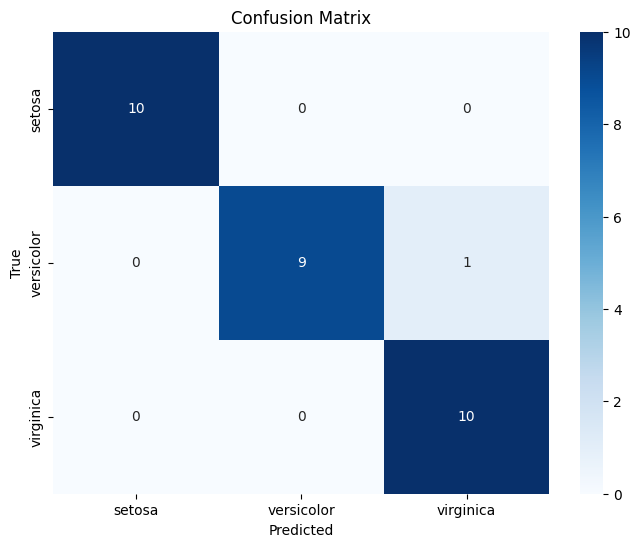

In [16]:
# plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

# define the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()